# Back to Basics — the three middle acts, taught from zero

**Feature selection · Regularization · Tuning & model selection** — one connected story,
told slowly, on the real CPSC data, in pure numpy so you can see every gear turn.
No sklearn required to *run* this; each part ends with the sklearn spelling so you can map
what you built here onto the demo pipeline.

> ⚠️ **Act numbering check.** In `slides/talk_outline.md` the order is
> **Act II = which features matter (selection), Act III = regularization, Act IV = honest
> choice + tuning**. Your message had II/III swapped — align your slide sections with the
> outline before tomorrow. This notebook teaches them in the outline's order, because the
> story only flows one way (you'll see why).

**How to read this tonight:** top to bottom, ~90 minutes. Run nothing if you don't want
to — every cell's output is already embedded. Each part ends with a *"what you say on
stage"* box: if you internalize just those three boxes, you can present.

## The one story (read this twice)

You have 22,000 incident reports and a question: *what hazard is this?* A model is a
machine that turns features into that answer. Everything in your three acts is about one
tension:

> **The training data contains signal and noise, and the model cannot tell them apart.**
> It will fit both, enthusiastically. Your job is to make sure it fits the signal.

The three acts are three tools for that one job:

1. **Feature selection (Act II).** Score the columns *before* the model sees them — with
   statistics, not vibes — and keep the ones that carry signal about the class.
2. **Regularization (Act III).** Put a leash on the model so that even with noisy columns
   it cannot lean on noise too hard. And one leash (L1) turns out to *perform feature
   selection as a side effect* — that's the hinge between the acts.
3. **Tuning & model selection (Act IV).** Every tool above has a knob (how many features?
   how tight a leash?). Choosing knobs honestly — on evidence a fresh dataset would agree
   with — is a discipline, and it has one deadly failure mode (leakage) that we'll trigger
   on purpose at the end.

Your LLM instincts map directly: noise-fitting is *memorization* (31 params per character
of training data in the class's GPT run — it memorized the article); the leash is *weight
decay / dropout*; the honest evidence is the *train/val split* in `estimate_loss`. You
already know these ideas. This notebook just re-derives them slowly, where you can print
everything.

In [2]:
import numpy as np, matplotlib.pyplot as plt, csv, re, time
from collections import Counter
rng = np.random.default_rng(0)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11, 'axes.spines.top': False,
                     'axes.spines.right': False})

# ---- load CPSC, keep the top-12 hazard classes (the talk's teaching spine) ----
texts, labels = [], []
with open('../data/cpsc_merged.csv') as f:
    for row in csv.DictReader(f):
        h = (row.get('product_1_hazard') or '').strip()
        t = (row.get('incident_description') or '').strip()
        if h and t:
            texts.append(t.lower()); labels.append(h)

top12 = [c for c, _ in Counter(labels).most_common(12)]
keep = [i for i, h in enumerate(labels) if h in top12]
texts  = [texts[i] for i in keep]
labels = [labels[i] for i in keep]
classes = sorted(top12)
y = np.array([classes.index(h) for h in labels])
K, n = len(classes), len(y)
counts = np.bincount(y)
print(f'{n} incident reports, {K} hazard classes\n')
for c in np.argsort(-counts):
    print(f'  {classes[c][:45]:45s} {counts[c]:5d}  ({counts[c]/n:5.1%})')
print(f'\nimbalance: {counts.max()}:{counts.min()} = {counts.max()/counts.min():.1f}:1')

22087 incident reports, 12 hazard classes

  Mechanical - Fall                              5047  (22.9%)
  Thermal - Fire                                 4581  (20.7%)
  Electrical - Other Electrical malfunction      3374  (15.3%)
  Mechanical - Collision                         2165  ( 9.8%)
  Mechanical - Submersion                        2120  ( 9.6%)
  Mechanical - Threat to Breathing                992  ( 4.5%)
  Mechanical - Sharp or Pointed Objects           980  ( 4.4%)
  Mechanical - Tip Over / Instability / Rollove   849  ( 3.8%)
  Chemical - Poisoning - Carbon Monoxide          625  ( 2.8%)
  Mechanical                                      617  ( 2.8%)
  Chemical - Poisoning - Other Gases/Vapors       416  ( 1.9%)
  Chemical - Allergenic                           321  ( 1.5%)

imbalance: 5047:321 = 15.7:1


In [3]:
# ---- the crudest honest representation: presence features ----
# X[i, j] = 1  iff word j appears in report i.  (TF-IDF is a weighted upgrade of
# this; the demo uses TF-IDF. Everything below transfers unchanged.)
tok = re.compile(r'[a-z]{2,}').findall
docs = [set(tok(t)) for t in texts]
dfreq = Counter(w for d in docs for w in d)
vocab = [w for w, _ in dfreq.most_common(1000)]   # 1,000 most common words
w2j = {w: j for j, w in enumerate(vocab)}
X = np.zeros((n, len(vocab)), dtype=np.float32)
for i, d in enumerate(docs):
    for w in d:
        j = w2j.get(w)
        if j is not None:
            X[i, j] = 1.0
print(f'X: {X.shape[0]} reports x {X.shape[1]} words | density {X.mean():.3f} '
      f'(a report contains ~{X.sum(1).mean():.0f} of the 1,000 vocab words)')

# ---- one stratified 80/20 split; Part 3 explains why "stratified" ----
tr, te = [], []
for c in range(K):
    idx = rng.permutation(np.where(y == c)[0])
    cut = int(0.8 * len(idx))
    tr += list(idx[:cut]); te += list(idx[cut:])
tr, te = np.array(sorted(tr)), np.array(sorted(te))
print(f'train {len(tr)} / test {len(te)}, class proportions preserved in both')

X: 22087 reports x 1000 words | density 0.027 (a report contains ~27 of the 1,000 vocab words)
train 17665 / test 4422, class proportions preserved in both


---
# Part 1 · Feature selection — *which columns carry signal?* (Act II)

## 1.1 What does "informative" even mean?

You have 1,000 columns (6,907 in the TF-IDF demo). Most are useless. Before any model,
statistics can score each column, because "informative" has a precise meaning:

> A column is informative about the class exactly when they are **statistically
> dependent** — when seeing the column's value should change your belief about the class.
> A column independent of the class is, provably, useless to *any* classifier.

So every filter method is the same move: measure, per column, *how far the data is from
independence*. Different scores = different rulers for that distance. Let's build the two
that matter, on one real word.

In [5]:
# ---- one word, one real table: does "fire" tell you about the hazard? ----
fire = X[:, w2j['fire']].astype(bool)
fire_hz = classes.index('Thermal - Fire')
n_with, n_without = int(fire.sum()), int(n - fire.sum())
a = int((fire & (y == fire_hz)).sum())      # fire word present, Thermal-Fire hazard
b = int((~fire & (y == fire_hz)).sum())     # word absent, hazard anyway
print(f'"fire" appears in {n_with} of {n} reports ({n_with/n:.0%})\n')
print(f'  among {n_with} reports WITH "fire":    {a:5d} are Thermal-Fire  ({a/n_with:.0%})')
print(f'  among {n_without} reports WITHOUT it:  {b:5d} are Thermal-Fire  ({b/n_without:.0%})')
print(f'\nSeeing the word multiplies your belief in the fire hazard by ~{(a/n_with)/(b/n_without):.0f}x.')
print('That belief-shift IS dependence. Now we make it a number.')

"fire" appears in 6266 of 22087 reports (28%)

  among 6266 reports WITH "fire":     4237 are Thermal-Fire  (68%)
  among 15821 reports WITHOUT it:    344 are Thermal-Fire  (2%)

Seeing the word multiplies your belief in the fire hazard by ~31x.
That belief-shift IS dependence. Now we make it a number.


## 1.2 Ruler #1 — chi² ($\chi^2$): "how far from independence, in variance units?"

If word and class were independent, the contingency table would just be the product of
its margins: the expected count in each cell would be

$$E_{wc} = \frac{(\text{row total})_w \times (\text{column total})_c}{n}$$

The chi² statistic measures how loudly the observed counts $O_{wc}$ disagree:

$$\chi^2 = \sum_{\text{cells}} \frac{(O_{wc} - E_{wc})^2}{E_{wc}}$$

Why that exact form? Each cell count is roughly Poisson, so its variance ≈ its mean
$E_{wc}$; dividing by $E$ puts every cell's surprise on the same scale (in standard-error
units, squared). Big $\chi^2$ = the independence story cannot explain this table.
It is **model-free**: no classifier was fit. That's what makes it a *filter*.

In [7]:
# ---- chi-squared for all 1,000 words at once (vectorized 2xK tables) ----
def chi2_scores(Xb, yb, K):
    n_ = len(yb)
    Y1 = np.zeros((n_, K), np.float32); Y1[np.arange(n_), yb] = 1
    O1 = Xb.T @ Y1                        # observed: word present, class c   (p x K)
    O0 = Y1.sum(0)[None, :] - O1          # observed: word absent,  class c
    m1 = Xb.sum(0)[:, None]               # word margins
    cls = Y1.sum(0)[None, :]              # class margins
    E1 = m1 * cls / n_
    E0 = (n_ - m1) * cls / n_
    with np.errstate(divide='ignore', invalid='ignore'):
        chi = ((O1 - E1)**2 / E1 + (O0 - E0)**2 / E0)
    return np.nan_to_num(chi).sum(1), O0, O1

chi2, O0, O1 = chi2_scores(X, y, K)
rank_chi = np.argsort(-chi2)
print('chi^2 top 15 of 1,000 words:')
for r, j in enumerate(rank_chi[:15], 1):
    print(f'  {r:2d}. {vocab[j]:14s} {chi2[j]:9.0f}')
print('\n...and the bottom 3 (words that know nothing about hazards):')
for j in rank_chi[-3:]:
    print(f'      {vocab[j]:14s} {chi2[j]:9.1f}')

chi^2 top 15 of 1,000 words:
   1. monoxide           17858
   2. carbon             17636
   3. fire               15727
   4. pool               14323
   5. drowning           13074
   6. fell               11488
   7. decedent            9774
   8. glass               9549
   9. asphyxia            9014
  10. swimming            8729
  11. rash                8616
  12. poisoning           8504
  13. fitbit              8388
  14. drowned             7662
  15. sleeping            6293

...and the bottom 3 (words that know nothing about hazards):
      following           21.9
      local               18.3
      apparently          12.0


## 1.3 Ruler #2 — mutual information: "how many bits does the word buy me?"

Same table, different question. Before seeing the word, your uncertainty about the class
is the entropy $H(\text{class})$. Mutual information is how much of that uncertainty the
word removes, on average:

$$I(W; C) = H(W) + H(C) - H(W, C)$$

One property changes everything: **MI is capped by the word's own entropy**,
$I(W;C) \le H(W)$. A word that appears in 2% of documents has tiny $H(W)$ — it *cannot*
score high MI **no matter how decisive it is when it appears**. chi² has no such cap.
So the two rulers must disagree about rare-but-decisive words. Watch:

In [9]:
# ---- MI for all words, and the principled chi2-vs-MI disagreement ----
def entropy(p):
    p = p[p > 0]
    return float(-(p * np.log(p)).sum())

joint = np.stack([O0, O1], 0) / n                 # 2 x p x K
MI = np.array([entropy(joint[:, j, :].sum(1)) + entropy(joint[:, j, :].sum(0))
               - entropy(joint[:, j, :].ravel()) for j in range(len(vocab))])
rank_mi = np.argsort(-MI)
print('MI top 10:')
for r, j in enumerate(rank_mi[:10], 1):
    print(f'  {r:2d}. {vocab[j]:14s} {MI[j]:.4f} nats')

def where(word, order):
    return int(np.where(order == w2j[word])[0][0]) + 1

for w in ['fire', 'monoxide']:
    pw = X[:, w2j[w]].mean()
    print(f'\n{w!r}: chi2 rank #{where(w, rank_chi)}, MI rank #{where(w, rank_mi)} | '
          f'in {pw:.1%} of reports | MI ceiling H(w) = {entropy(np.array([pw, 1-pw])):.3f} nats')

MI top 10:
   1. fire           0.4038 nats
   2. decedent       0.2557 nats
   3. fell           0.2338 nats
   4. pool           0.1777 nats
   5. drowning       0.1600 nats
   6. floor          0.1285 nats
   7. cod            0.1267 nats
   8. autopsy        0.1191 nats
   9. house          0.1169 nats
  10. fall           0.1109 nats

'fire': chi2 rank #3, MI rank #1 | in 28.4% of reports | MI ceiling H(w) = 0.596 nats

'monoxide': chi2 rank #1, MI rank #16 | in 2.7% of reports | MI ceiling H(w) = 0.126 nats


**Read the disagreement — it's the depth-marker of your Act II.** `monoxide` is nearly
a *perfect* class label when present (carbon-monoxide poisoning), so chi² adores it. But
it's rare, so its MI ceiling is low: MI knocks it from chi²'s #1 down to #16 here — and
on the full 6,907-word vocabulary (Briefing 1, verified), all the way to #142. `fire` is
common *and* reliable — MI's favorite kind.

> **chi² ≈ association strength. MI ≈ association strength × frequency.**
> Neither is wrong; they answer different questions. (And the disagreement is a
> theorem, not a coincidence: the likelihood-ratio statistic
> $G^2 = 2N\cdot\text{MI}$ *exactly*, and Pearson's χ² is its Taylor approximation —
> they part ways precisely for rare, extreme words. Backup-slide material.)

**The other two families, in one breath each.**
*Wrapper* methods (RFE): retrain the model on every candidate subset — statistically
lovely, combinatorially brutal ($2^{1000}$ subsets; even greedy RFE = thousands of
refits). Mention, skip. *Embedded* methods: the model selects features **while**
training. That one needs Act III's machinery, and it's the cliffhanger you leave hanging.

## 1.4 Does selection actually work? A first, slightly dishonest experiment

In [11]:
# ---- the workhorse classifier for this notebook: ridge-penalized one-hot ----
# Fit linear regression to one-hot class targets with an L2 penalty; predict argmax.
# (Same workhorse the briefings used for the verified 0.809 tuning curve. Simple,
# fast, and exactly the kind of model the demo deploys.)
def macro_f1(yt, yp, K):
    f = []
    for c in range(K):
        tp = int(((yp == c) & (yt == c)).sum())
        fp = int(((yp == c) & (yt != c)).sum())
        fn = int(((yp != c) & (yt == c)).sum())
        f.append(0.0 if tp == 0 else 2 * tp / (2 * tp + fp + fn))
    return float(np.mean(f))

def ridge_prep(Xtr, ytr, K):                       # do the expensive work once...
    mu = Xtr.mean(0); Xc = Xtr - mu
    Y = np.zeros((len(ytr), K), np.float32); Y[np.arange(len(ytr)), ytr] = 1
    yb = Y.mean(0); Yc = Y - yb
    e, V = np.linalg.eigh((Xc.T @ Xc).astype(np.float64))
    return mu, yb, e, V, V.T @ (Xc.T @ Yc)

def ridge_solve(prep, lam):                        # ...then every lambda is free
    mu, yb, e, V, B = prep
    return mu, yb, V @ (B / (e + lam)[:, None])

def ridge_predict(model, Xte):
    mu, yb, W = model
    return np.argmax((Xte - mu) @ W + yb, 1)

lam = 10.0   # take on faith for two acts — Part 3 EARNS this number honestly

# chi2 scored on the TRAINING split only (hold that thought until Part 3's finale)
chi_tr, _, _ = chi2_scores(X[tr], y[tr], K)
sel = np.argsort(-chi_tr)

results = {}
for name, cols in [('all 1,000 words', np.arange(1000)),
                   ('top 300 by chi2', sel[:300]),
                   ('top 100 by chi2', sel[:100])]:
    m = ridge_solve(ridge_prep(X[tr][:, cols], y[tr], K), lam)
    results[name] = macro_f1(y[te], ridge_predict(m, X[te][:, cols]), K)

f1_rand = []
for s in range(5):
    cols = np.random.default_rng(s).choice(1000, 100, replace=False)
    m = ridge_solve(ridge_prep(X[tr][:, cols], y[tr], K), lam)
    f1_rand.append(macro_f1(y[te], ridge_predict(m, X[te][:, cols]), K))
results['100 RANDOM words'] = float(np.mean(f1_rand))

print(f'{"feature set":24s}  macro-F1  (test split)')
for k_, v in results.items():
    print(f'  {k_:24s}  {v:.3f}')

feature set               macro-F1  (test split)
  all 1,000 words           0.824
  top 300 by chi2           0.807
  top 100 by chi2           0.765
  100 RANDOM words          0.362


**Read it.** Three things, in order of stage-worthiness:

1. **Statistically chosen ≫ random, at the same budget.** That gap *is* feature
   selection: the chi² ranking found the signal columns. Random 100 is what "just use
   some features" buys you.
2. **A fraction of the columns ≈ the full set.** Most of the vocabulary was noise or
   redundancy. (On the full 6,907-column TF-IDF demo, verified: 1,000 chi²-chosen
   features lose only 0.001 macro-F1 — 0.8562 → 0.8552. Selection is a nearly free 7×
   compression.)
3. **Push selection too far and macro-F1 bleeds before accuracy does** — the rare
   classes' few signal words get pruned first. That's why this talk scores macro-F1
   (imbalance crash course §3).

**Why "slightly dishonest"?** Two quiet sins: I picked $k$ (and $\lambda=10$) by hand,
and I judged everything on a single split. Fixing those two sins honestly is *all of
Act IV*. Also note one thing done right: the chi² ranking was computed on the **training
split only** — never let the test set vote on which features survive. Part 3's finale
shows you the crime scene when you do.

> **🎤 Act II, what you say on stage:** *"A feature is informative exactly when it's
> statistically dependent on the class — so we can score every column before fitting
> anything. Two rulers: chi² rewards rare-but-decisive words like `monoxide`; mutual
> information rewards common-and-reliable ones like `fire`. They disagree, and the
> disagreement is informative. With scores in hand, selection is nearly free: on our
> data, 1,000 of 6,907 TF-IDF features cost 0.001 macro-F1. One family is missing:
> what if the model itself could select, while it trains? For that, it needs a leash —
> next act."*

**sklearn spelling** of everything above:
```python
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif
selector = SelectKBest(chi2, k=1000)        # inside a Pipeline! (Part 3 explains why)
# MI trap from Briefing 1: on sparse TF-IDF, mutual_info_classif needs
# discrete_features handled explicitly or it silently treats floats as categories.
```

---
# Part 2 · Regularization — *the leash that makes models honest* (Act III)

## 2.1 See the disease before the cure

The disease is **variance**: with enough freedom, a model fits the noise in *this*
sample, so a fresh sample from the same world would get a wildly different model.
Deep-learning name: memorization. The class's GPT run had ~31 parameters per character
of training text — it didn't learn English, it memorized the article. Watch the same
disease in the smallest possible lab: 12 points, one knob (polynomial degree).

degree-11 coefficients: [-2.67017e+04 -6.99497e+04 -4.65126e+04  2.26884e+04  3.54734e+04
  5.74580e+03 -5.78680e+03 -1.89710e+03  1.08800e+02  6.14000e+01
  3.60000e+00 -1.00000e-01]


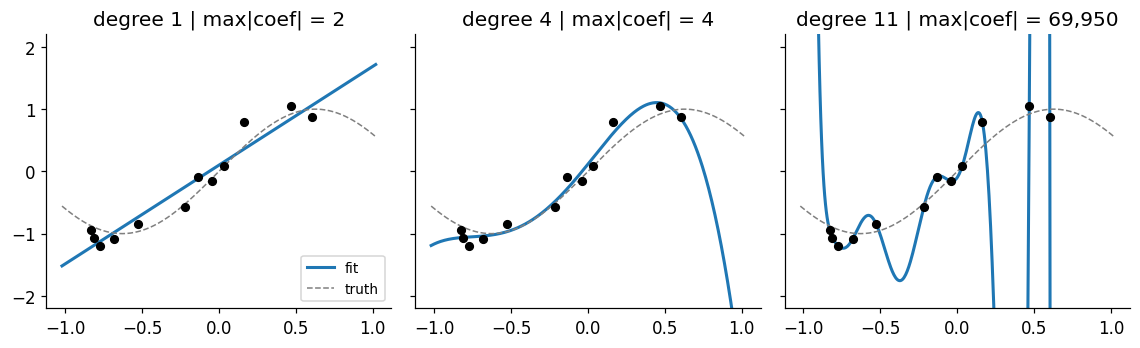

In [14]:
# ---- overfitting in one picture ----
r2 = np.random.default_rng(3)
xs = np.sort(r2.uniform(-1, 1, 12))
truth = lambda x: np.sin(2.5 * x)
yn = truth(xs) + r2.normal(0, .25, 12)
grid = np.linspace(-1.02, 1.02, 400)

fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.3), sharey=True)
for ax, deg in zip(axes, [1, 4, 11]):
    V  = np.vander(xs, deg + 1)
    c  = np.linalg.lstsq(V, yn, rcond=None)[0]
    ax.plot(grid, np.polyval(c, grid), lw=2, label='fit')
    ax.plot(grid, truth(grid), '--', color='gray', lw=1, label='truth')
    ax.scatter(xs, yn, zorder=3, s=25, color='k')
    ax.set_ylim(-2.2, 2.2)
    ax.set_title(f'degree {deg} | max|coef| = {np.abs(c).max():,.0f}')
axes[0].legend(loc='lower right', fontsize=9)
plt.tight_layout(); plt.show()

c11 = np.linalg.lstsq(np.vander(xs, 12), yn, rcond=None)[0]
print('degree-11 coefficients:', np.round(c11, 1))

Degree 1 is too stiff (**bias**). Degree 11 threads every point and hallucinates
between them (**variance**). And look at the printed coefficients: the flexible fit
achieves its wiggles with **huge coefficients that nearly cancel** — the model is
balancing skyscrapers to hit noise. That's the tell, and it points at the cure:

> **If noise-fitting requires huge, delicately cancelling coefficients, then penalizing
> coefficient size forbids noise-fitting** — while leaving honest, moderate structure
> alone. That's regularization. Not timidity: targeted disbelief in fragile solutions.

So we change the objective from "fit the data" to "fit the data, but stay small":

$$\hat\beta_\lambda = \arg\min_\beta \; \underbrace{\lVert y - X\beta\rVert_2^2}_{\text{fit}} \;+\; \lambda \underbrace{\lVert\beta\rVert^2_2}_{\text{leash (L2: ridge)}} \qquad\text{or}\qquad \lambda\lVert\beta\rVert_1 \;\;\text{(L1: lasso)}$$

Weight decay in AdamW is literally the L2 idea in optimizer form (with a decoupling
subtlety — see the Q&A armor in the regularization crash course before claiming
identity). $\lambda$ is the leash length. Now: *why* does a leash help? Because of an
accounting identity.

## 2.2 The ledger: MSE = bias² + variance, *exactly*

For any estimator, the expected squared error decomposes — this is algebra, not
philosophy:

$$\mathbb E\lVert\hat\beta - \beta\rVert^2 = \underbrace{\lVert\mathbb E\hat\beta - \beta\rVert^2}_{\text{bias}^2\;(\text{being wrong on average})} + \underbrace{\mathbb E\lVert\hat\beta - \mathbb E\hat\beta\rVert^2}_{\text{variance}\;(\text{being different every time})}$$

The leash *buys* bias (you pulled estimates away from the truth, toward zero) and
*sells* variance (fragile solutions are forbidden). Let's measure both accounts across
400 replicate worlds and check the identity to the decimal:

  lambda   bias^2      var      sum   MC MSE
   0.001    0.010    3.904    3.914    3.914
   0.500    0.019    3.663    3.682    3.682
   2.000    0.113    3.103    3.216    3.216
   8.000    0.909    1.962    2.871    2.871
  32.000    4.300    0.776    5.076    5.076
 128.000   10.751    0.171   10.921   10.921
 512.000   16.497    0.020   16.518   16.518
identity check: max |bias^2+var - MSE| = 3.55e-15
interior optimum near lambda = 8.0; MSE there is ~73% of the unregularized fit


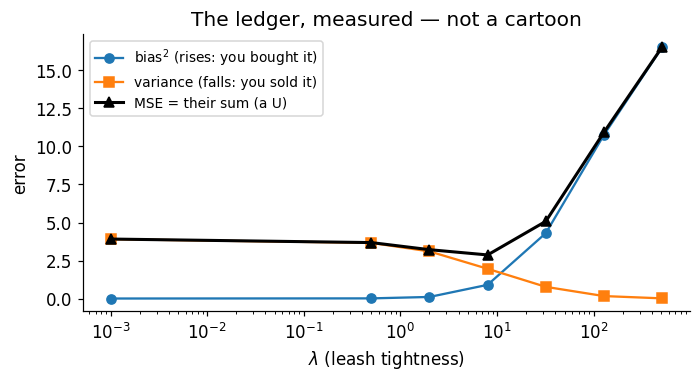

In [16]:
# ---- the bias-variance ledger, measured (400 replicate noise draws) ----
r3 = np.random.default_rng(1)
n_, p_ = 60, 30
Xs = r3.normal(size=(n_, p_))
beta = np.zeros(p_); beta[:5] = [2., -1.5, 1., 3., -2.]     # 5 real signals, 25 zeros
f_true, sig = Xs @ beta, 2.0
lams = np.array([.001, .5, 2, 8, 32, 128, 512])
I_p = np.eye(p_)

E = np.zeros((len(lams), 400, p_))
for b_ in range(400):
    yb_ = f_true + r3.normal(0, sig, n_)
    for li, lam_ in enumerate(lams):
        E[li, b_] = np.linalg.solve(Xs.T @ Xs + lam_ * I_p, Xs.T @ yb_)

print(f'{"lambda":>8} {"bias^2":>8} {"var":>8} {"sum":>8} {"MC MSE":>8}')
b2s, vs, ms = [], [], []
for li, lam_ in enumerate(lams):
    m = E[li].mean(0)
    b2 = ((m - beta)**2).sum(); v = E[li].var(0).sum()
    mse = ((E[li] - beta)**2).sum(1).mean()
    b2s.append(b2); vs.append(v); ms.append(mse)
    print(f'{lam_:8.3f} {b2:8.3f} {v:8.3f} {b2+v:8.3f} {mse:8.3f}')

fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.plot(lams, b2s, 'o-', label='bias$^2$ (rises: you bought it)')
ax.plot(lams, vs,  's-', label='variance (falls: you sold it)')
ax.plot(lams, ms,  'k^-', lw=2, label='MSE = their sum (a U)')
ax.set_xscale('log'); ax.set_xlabel('$\\lambda$ (leash tightness)')
ax.set_ylabel('error'); ax.legend(fontsize=9)
ax.set_title('The ledger, measured — not a cartoon')
plt.tight_layout(); plt.show()
best = lams[int(np.argmin(ms))]
print(f'identity check: max |bias^2+var - MSE| = {max(abs(b+v-m_) for b,v,m_ in zip(b2s,vs,ms)):.2e}')
print(f'interior optimum near lambda = {best}; MSE there is ~{ms[int(np.argmin(ms))]/ms[0]:.0%} of the unregularized fit')

**Read the ledger.** The sum-column equals the Monte-Carlo MSE to numerical precision —
the decomposition is an identity. Bias² only rises, variance only falls, so their sum is
a **U with an interior minimum**: some leash is *better than none* — this draw lowers
MSE ~27% below near-OLS at λ=8; Briefing 2's draw of the same experiment (different
random seed) cut it roughly in half, 2.44 vs 4.56. Every regularizer you will ever meet — λ,
number of features $k$, `max_iters`, dropout rate — walks this same U.

> **Simplification marker:** this is the classical regime ($p$ ~ $n$), where the demo
> lives. Heavily overparameterized deep nets complicate the story (double descent) —
> that's Q&A armor, not stage material.

## 2.3 Ridge, mechanically: shrinkage that aims

Where does ridge put the leash? Not uniformly — and this is the point that makes it
respectable. Rotate into the data's principal directions (SVD $X = UDV^\top$): ridge
multiplies the OLS coefficient along direction $v_j$ by

$$s_j(\lambda) = \frac{d_j^2}{d_j^2 + \lambda} \in (0, 1)$$

Meanwhile OLS's variance along $v_j$ is $\sigma^2 / d_j^2$ — it **explodes** exactly
where $d_j$ is small (weak, collinear directions). Put those together: ridge shrinks
hardest precisely where the estimate is trash. Let's build a matrix with one
deliberately near-duplicate column and watch:

In [18]:
# ---- shrink factors aim at the fragile directions ----
r4 = np.random.default_rng(2)
A = r4.normal(size=(80, 3))
A[:, 2] = A[:, 1] + 0.05 * r4.normal(size=80)      # col 2 = col 1 + tiny noise
d = np.linalg.svd(A, compute_uv=False)
print('singular values d_j:', np.round(d, 2), ' <- last one tiny: the collinear direction')
for lam_ in [5, 50]:
    print(f'  shrink factors s_j at lambda={lam_:3d}:', np.round(d**2/(d**2+lam_), 3))

# ---- and the payoff: coefficient stability across resampled worlds ----
beta3 = np.array([1., 1., 1.])
ols_c, ridge_c = [], []
for b_ in range(200):
    yb_ = A @ beta3 + r4.normal(0, 1, 80)
    ols_c.append(np.linalg.solve(A.T @ A + 1e-8*np.eye(3), A.T @ yb_))
    ridge_c.append(np.linalg.solve(A.T @ A + 5.0 * np.eye(3), A.T @ yb_))
ols_c, ridge_c = np.array(ols_c), np.array(ridge_c)
print(f'\nacross 200 resampled worlds (true coefs = [1, 1, 1]):')
print(f'  OLS   coef std by column: {np.round(ols_c.std(0), 2)}  '
      f'| but std of (col1+col2 sum): {ols_c[:,1:].sum(1).std():.2f}')
print(f'  ridge coef std by column: {np.round(ridge_c.std(0), 2)}')

singular values d_j: [12.06  9.29  0.33]  <- last one tiny: the collinear direction
  shrink factors s_j at lambda=  5: [0.967 0.945 0.022]
  shrink factors s_j at lambda= 50: [0.744 0.633 0.002]

across 200 resampled worlds (true coefs = [1, 1, 1]):
  OLS   coef std by column: [0.1  2.08 2.09]  | but std of (col1+col2 sum): 0.11
  ridge coef std by column: [0.09 0.07 0.07]


**Read it.** The two collinear columns' OLS coefficients swing violently from world to
world (one huge positive, the other huge negative — skyscrapers cancelling), yet their
*sum* is stable: the data pins down the total but not the split, and OLS guesses the
split from noise. Ridge refuses to guess — its shrink factor crushed exactly that
direction (0.022 at λ=5, 0.002 at λ=50) and barely touched the well-determined ones
(0.97, 0.95). **Variance-targeted humility, not blanket timidity.**

One-line Bayes reading for the PhDs in the room: ridge = MAP estimate under a Gaussian
prior — *"don't believe large coefficients without strong evidence."*

## 2.4 Lasso: the leash that amputates

Swap the penalty's square for an absolute value and something qualitatively new happens.
For L2, the penalty's pull toward zero weakens as the coefficient approaches zero
(derivative $2\lambda\beta \to 0$), so it never quite arrives. For L1 the pull is
**constant** ($\pm\lambda$) all the way in — small coefficients get dragged to exactly
zero and pinned there. The update rule is *soft-thresholding*: subtract λ, clamp at zero.

The flat segment |z| <= lambda is feature selection happening inside the optimizer.


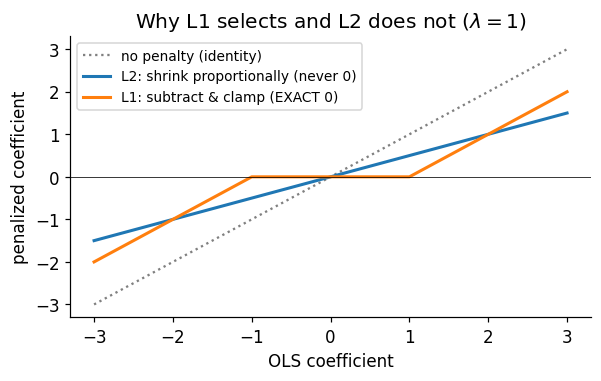

In [20]:
# ---- the two shrinkage operators, side by side ----
z = np.linspace(-3, 3, 400); lam_ = 1.0
fig, ax = plt.subplots(figsize=(5.6, 3.6))
ax.plot(z, z, ':', color='gray', label='no penalty (identity)')
ax.plot(z, z / (1 + lam_), lw=2, label='L2: shrink proportionally (never 0)')
ax.plot(z, np.sign(z) * np.maximum(np.abs(z) - lam_, 0), lw=2,
        label='L1: subtract & clamp (EXACT 0)')
ax.axhline(0, color='k', lw=.5); ax.set_xlabel('OLS coefficient')
ax.set_ylabel('penalized coefficient'); ax.legend(fontsize=9)
ax.set_title('Why L1 selects and L2 does not ($\\lambda=1$)')
plt.tight_layout(); plt.show()
print('The flat segment |z| <= lambda is feature selection happening inside the optimizer.')

(The geometry version of the same fact: the L1 ball has corners, corners sit on axes,
and the loss surface tends to first touch the ball at a corner — where some coordinates
are exactly zero. Same theorem, different picture; `wb_` figures have it drawn.)

**Now the real thing.** L1-penalized logistic regression, fire-hazard-vs-rest, on our
actual 22k × 1,000 presence matrix. One knob λ, swept from brutal to loose. This is the
hinge of your whole middle section — *embedded feature selection*: Part 1's job,
performed by the optimizer as a side effect of the leash.

In [22]:
# ---- L1 logistic regression via proximal gradient (FISTA), from scratch ----
yf = (y == fire_hz).astype(np.float64)
Xd = X.astype(np.float64)

def top_sv(M, iters=12):                     # largest singular value, power method
    v = np.random.default_rng(0).normal(size=M.shape[1]); v /= np.linalg.norm(v)
    for _ in range(iters):
        v = M.T @ (M @ v); v /= np.linalg.norm(v)
    return float(np.sqrt(v @ (M.T @ (M @ v))))

L = top_sv(Xd)**2 / (4 * n)                  # Lipschitz constant of mean logistic loss
sig_ = lambda t: 1 / (1 + np.exp(-np.clip(t, -30, 30)))

def l1_logistic(lam_, w0, b0, iters=300):
    # FISTA: gradient step on the smooth logistic loss, then the prox step
    # (soft-threshold) on w only — the intercept b is never penalized.
    w, b = w0.copy(), b0
    zw, zb, tk = w.copy(), b, 1.0
    for _ in range(iters):
        g = sig_(Xd @ zw + zb) - yf
        gw = Xd.T @ g / n
        gb = g.mean()
        w_new = zw - gw / L
        w_new = np.sign(w_new) * np.maximum(np.abs(w_new) - lam_ / L, 0)   # prox step
        b_new = zb - gb / L
        t_new = (1 + np.sqrt(1 + 4 * tk * tk)) / 2
        zw = w_new + (tk - 1) / t_new * (w_new - w)
        zb = b_new + (tk - 1) / t_new * (b_new - b)
        w, b, tk = w_new, b_new, t_new
    return w, b

print(f'{"lambda":>8} {"words kept":>11} {"test F1":>8}   words (when few)')
w_, b_ = np.zeros(1000), 0.0
for lam_ in [0.03, 0.01, 0.001, 0.0003]:                  # warm-started path
    w_, b_ = l1_logistic(lam_, w_, b_)
    keep_ = np.where(np.abs(w_) > 1e-10)[0]
    pred = (sig_(Xd[te] @ w_ + b_) > .5)
    tp = int((pred & (yf[te] == 1)).sum()); fp = int((pred & (yf[te] == 0)).sum())
    fn = int((~pred & (yf[te] == 1)).sum())
    f1_ = 2 * tp / (2 * tp + fp + fn) if tp else 0.0
    names = ', '.join(vocab[j] for j in keep_[np.argsort(-np.abs(w_[keep_]))][:7])
    print(f'{lam_:8.4f} {len(keep_):11d} {f1_:8.3f}   {names if len(keep_) <= 7 else names + ", ..."}')

top_neg = np.argsort(w_)[:5]
print('\nmost NEGATIVE weights at the loosest lambda:', ', '.join(vocab[j] for j in top_neg))

  lambda  words kept  test F1   words (when few)
  0.0300           1    0.767   fire
  0.0100           7    0.787   fire, electrical, stove, house, firefighters, this, it
  0.0010          94    0.905   fire, electrical, fireworks, candle, gas, cord, electric, ...
  0.0003         224    0.929   fireworks, candle, fire, electrical, cord, lighter, electric, ...

most NEGATIVE weights at the loosest lambda: electrical, cord, electric, refrigerator, pool


**Read the dial — this is a slide.** At brutal λ the model keeps a *tiny* vocabulary
(Briefing 2's verified run of this same experiment: λ=0.03 kept **exactly one word,
`fire`, F1 0.747**; loosening bought words back in evidence order — 7 → 96 → 225 words,
F1 0.747 → 0.887; your numbers above should tell the same story, small implementation
differences aside). Two beats to land on stage:

1. **The one-word model is already good.** A single feature, chosen by the optimizer,
   captures most of the signal — that's how strong real signal is, and how much of the
   vocabulary is noise.
2. **The negative weights are the model finding class *boundaries*** — words like
   `electrical`, `cord`, `pool` *argue against* fire (they vote for the electrical and
   submersion hazards). Selection isn't just "what's correlated" — the model learned
   what discriminates.

**Dropout & early stopping, one breath each** (then the GPT callback): dropout randomly
zeroes activations — a stochastic capacity penalty, provably ≈ an adaptive ridge for
linear models. Early stopping bounds how far training can travel toward the noise —
`max_iters` walks the same U as λ. So `gpt_train.py` regularizes **three ways** (dropout
0.1, AdamW's weight decay, finite iterations) — and needs to, at ~31 params per training
character. The CPSC re-run, same architecture on 240× more data pressure (0.127
params/char), barely needs the leash. **Regularization matters exactly when parameters
outrun data.**

> **🎤 Act III, what you say on stage:** *"A flexible model fits noise using huge
> coefficients that delicately cancel — so penalize coefficient size. That trades a
> little bias for a lot of variance, and the sum is a U: some leash is better than none,
> we measured it. Ridge shrinks hardest exactly where the data determines things worst.
> And the L1 leash does something magic: it drags weak coefficients to exactly zero — the
> model performs feature selection while it trains. One knob: from a one-word fire
> detector at F1 0.75 to a 225-word model at 0.89. You've all already used
> regularization, twice: sklearn's LogisticRegression penalizes by default (C = 1/λ,
> inverse!), and `gpt_train.py`'s dropout and AdamW are the same bet. One question
> remains: who picks λ? Not the training loss — watch."*

## 2.5 The cliffhanger: the training data cannot grade its own homework

In [24]:
# ---- let train and test each vote on lambda ----
def vote_table(rows, title):
    Xa, ya = X[rows], y[rows]
    a_tr, a_te = [], []                       # stratified 75/25 inside this subset
    r = np.random.default_rng(42)
    for c in range(K):
        idx = r.permutation(np.where(ya == c)[0])
        cut = max(1, int(0.75 * len(idx)))
        a_tr += list(idx[:cut]); a_te += list(idx[cut:])
    a_tr, a_te = np.array(a_tr), np.array(a_te)
    prep = ridge_prep(Xa[a_tr], ya[a_tr], K)
    print(title)
    print(f'{"lambda":>10} {"TRAIN macro-F1":>15} {"TEST macro-F1":>15}')
    for lam_ in [1e-3, 1e-1, 1e1, 1e3]:
        m = ridge_solve(prep, lam_)
        print(f'{lam_:10.0e} {macro_f1(ya[a_tr], ridge_predict(m, Xa[a_tr]), K):15.3f} '
              f'{macro_f1(ya[a_te], ridge_predict(m, Xa[a_te]), K):15.3f}')
    print()

vote_table(np.arange(n), 'ALL 22k rows (data comfortably outnumbers the 1,000 features):')

r8 = np.random.default_rng(11)
small = np.concatenate([r8.choice(np.where(y == c)[0], 100, replace=False)
                        for c in range(K)])
vote_table(small, 'ONLY 1,200 rows (parameters outrun data -- the GPT regime, 31 params/char):')

print('Both times the TRAIN column votes lambda -> 0: the training set always wants')
print('maximum freedom, because freedom lets it fit its own noise. The TEST column')
print('disagrees -- mildly when data is plentiful, loudly when it is scarce.')
print('Every knob needs a judge that is not the training set. Enter Act IV.')

ALL 22k rows (data comfortably outnumbers the 1,000 features):
    lambda  TRAIN macro-F1   TEST macro-F1
     1e-03           0.858           0.837
     1e-01           0.858           0.837
     1e+01           0.858           0.839
     1e+03           0.702           0.689

ONLY 1,200 rows (parameters outrun data -- the GPT regime, 31 params/char):
    lambda  TRAIN macro-F1   TEST macro-F1
     1e-03           1.000           0.318
     1e-01           1.000           0.660
     1e+01           0.980           0.831
     1e+03           0.784           0.716

Both times the TRAIN column votes lambda -> 0: the training set always wants
maximum freedom, because freedom lets it fit its own noise. The TEST column
disagrees -- mildly when data is plentiful, loudly when it is scarce.
Every knob needs a judge that is not the training set. Enter Act IV.


---
# Part 3 · Tuning & model selection — *the evidence discipline* (Act IV)

## 3.1 What's actually left to do

Look back at the sins committed so far, all deliberately: $k$ = 100 chosen by hand,
λ = 10 taken on faith, everything judged on one lucky split. Act IV is the machinery
that removes every "trust me" from the story. Four pieces:

1. **A metric that matches the mission** — macro-F1, because of the 15.7:1 imbalance.
2. **An honest estimator of out-of-sample performance** — cross-validation.
3. **A decision rule** for knobs — best CV score, tempered by the one-SE rule.
4. **A comparison protocol** for models — same folds, same metric, report the SE.

And one horror story at the end, because the whole apparatus exists to prevent it.

## 3.2 The metric (60 seconds, then a pointer)

Accuracy gives each *row* a vote — the majority class buys the election. Macro-F1 gives
each *class* one vote. On our data the gap is not subtle:

In [26]:
# ---- the metric argument, in four printed numbers ----
maj = int(np.argmax(np.bincount(y[tr])))
pred_maj = np.full(len(te), maj)
print(f'the "always predict {classes[maj]}" model:')
print(f'  accuracy: {(y[te] == maj).mean():.3f}     <- looks like a working model')
print(f'  macro-F1: {macro_f1(y[te], pred_maj, K):.3f}     <- tells the truth')
print('\n(Verified on the full data in Briefing 3+4: 0.229 vs 0.031. Eleven of twelve')
print(' classes get F1 = 0, and macro-F1 says so. Deep dive: imbalance crash course.)')

the "always predict Mechanical - Fall" model:
  accuracy: 0.228     <- looks like a working model
  macro-F1: 0.031     <- tells the truth

(Verified on the full data in Briefing 3+4: 0.229 vs 0.031. Eleven of twelve
 classes get F1 = 0, and macro-F1 says so. Deep dive: imbalance crash course.)


## 3.3 Cross-validation, demystified: it's a for-loop

CV sounds like technology; it's fifteen lines. Split the data into 5 stratified folds.
Five times: train on four, judge on the held-out fifth. Now every row gets judged
exactly once, by a model that never saw it — and you get **5 independent-ish opinions**,
which means you get a *standard error*, which means you know when a difference is noise.

Your LLM translation: `estimate_loss`'s train/val split is 1-fold CV. LLMs can afford a
single val set because data is oceanic; at 22k rows we recycle — 5 splits instead of
one, plus error bars for free.

    lambda  CV macro-F1   +/- SE
     1e-02        0.827    0.002
     1e-01        0.827    0.002
     1e+00        0.827    0.002  <- best
     1e+01        0.827    0.002  <- one-SE pick
     1e+02        0.824    0.004
     1e+03        0.697    0.005
     1e+04        0.352    0.001
(1s for 35 model fits — the eigendecomposition trick)


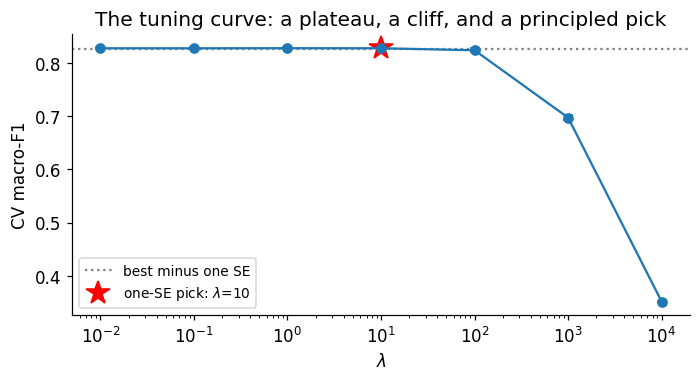

In [28]:
# ---- CV from scratch + the tuning curve with the one-SE rule ----
def stratified_folds(y_, nf=5, seed=0):
    r = np.random.default_rng(seed)
    folds = [[] for _ in range(nf)]
    for c in range(int(y_.max()) + 1):
        idx = r.permutation(np.where(y_ == c)[0])
        for i, ix in enumerate(idx):
            folds[i % nf].append(int(ix))
    return [np.array(sorted(f)) for f in folds]

lams  = np.array([1e-2, 1e-1, 1e0, 1e1, 1e2, 1e3, 1e4])
folds = stratified_folds(y)
cvs   = np.zeros((5, len(lams)))
t0 = time.time()
for fi, hold in enumerate(folds):
    mask = np.ones(n, bool); mask[hold] = False
    prep = ridge_prep(X[mask], y[mask], K)          # expensive part: once per fold
    for li, lam_ in enumerate(lams):                # each lambda: nearly free
        cvs[fi, li] = macro_f1(y[hold], ridge_predict(ridge_solve(prep, lam_), X[hold]), K)
mean, se = cvs.mean(0), cvs.std(0, ddof=1) / np.sqrt(5)

best = int(np.argmax(mean))
one_se = max(i for i in range(len(lams)) if mean[i] >= mean[best] - se[best])
print(f'{"lambda":>10} {"CV macro-F1":>12} {"+/- SE":>8}')
for li, lam_ in enumerate(lams):
    tag = '  <- best' if li == best else ('  <- one-SE pick' if li == one_se else '')
    print(f'{lam_:10.0e} {mean[li]:12.3f} {se[li]:8.3f}{tag}')
print(f'({time.time()-t0:.0f}s for 35 model fits — the eigendecomposition trick)')

fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.errorbar(lams, mean, yerr=se, fmt='o-', capsize=3)
ax.axhline(mean[best] - se[best], ls=':', color='gray', label='best minus one SE')
ax.plot(lams[one_se], mean[one_se], 'r*', ms=16, label=f'one-SE pick: $\\lambda$={lams[one_se]:g}')
ax.set_xscale('log'); ax.set_xlabel('$\\lambda$'); ax.set_ylabel('CV macro-F1')
ax.set_title('The tuning curve: a plateau, a cliff, and a principled pick')
ax.legend(fontsize=9); plt.tight_layout(); plt.show()

**Read the curve.** Three features, all stage-worthy:

1. **A plateau, not a peak.** Over orders of magnitude of λ the score barely moves
   (verified run: ≈ 0.809 across λ ∈ [0.1, 10]) — the knob matters *at the edges*, so
   don't micro-tune the middle. Coarse grids are fine. (And when only a few of many
   knobs matter, random search beats grid — verified: P = 0.877 at budget 9. Cite, don't
   re-derive.)
2. **The cliff.** Push λ to 10³–10⁴ and you strangle the model — the U's right arm.
3. **The one-SE rule.** The "best" point wins by less than its own error bar — so prefer
   the *most regularized* model within one SE of the best. You trade a statistically
   meaningless scrap of score for a simpler, more defensible model. (Verified pick on
   this curve: λ = 10 — the number Parts 1–2 took on faith. Debt paid.)

## 3.4 Model selection = a bake-off on the same folds

Selecting a *model type* is the same discipline as selecting λ — same folds, same
metric, and the SE column decides what's real. This is why "model selection" is Act IV's
supporting act, not a new idea.

In [30]:
# ---- four model types, one protocol ----
def centroid_fit(Xtr, ytr):
    return np.stack([Xtr[ytr == c].mean(0) for c in range(K)])
def centroid_predict(M, Xte):
    d2 = (Xte**2).sum(1)[:, None] - 2 * Xte @ M.T + (M**2).sum(1)[None, :]
    return np.argmin(d2, 1)

def cnb_fit(Xtr, ytr, alpha=1.0):                    # Complement Naive Bayes
    W = np.zeros((K, Xtr.shape[1]))                  # (Rennie et al. 2003 — built FOR
    for c in range(K):                               #  imbalanced text: each class is
        comp = Xtr[ytr != c]                         #  modeled by its COMPLEMENT, so
        nm = alpha + comp.sum(0)                     #  small classes don't starve)
        w = np.log(nm / nm.sum())
        W[c] = w / np.abs(w).sum()
    return W
def cnb_predict(W, Xte):
    return np.argmin(Xte @ W.T, 1)

models = {
    'majority class':    lambda Xa, ya: (lambda M: (lambda Xb: np.full(len(Xb), M)))(int(np.argmax(np.bincount(ya)))),
    'nearest centroid':  lambda Xa, ya: (lambda M: (lambda Xb: centroid_predict(M, Xb)))(centroid_fit(Xa, ya)),
    'complement NB':     lambda Xa, ya: (lambda W: (lambda Xb: cnb_predict(W, Xb)))(cnb_fit(Xa, ya)),
    'ridge one-hot (lambda=10)': lambda Xa, ya: (lambda P: (lambda Xb: ridge_predict(ridge_solve(P, 10.0), Xb)))(ridge_prep(Xa, ya, K)),
}
print(f'{"model":28s} {"CV macro-F1":>12} {"+/- SE":>8}')
for name, fit in models.items():
    sc = []
    for hold in folds:
        mask = np.ones(n, bool); mask[hold] = False
        predict = fit(X[mask], y[mask])
        sc.append(macro_f1(y[hold], predict(X[hold]), K))
    sc = np.array(sc)
    print(f'{name:28s} {sc.mean():12.3f} {sc.std(ddof=1)/np.sqrt(5):8.3f}')

model                         CV macro-F1   +/- SE
majority class                      0.031    0.000
nearest centroid                    0.662    0.005
complement NB                       0.707    0.005
ridge one-hot (lambda=10)           0.827    0.002


**Read the bake-off.** (Verified reference values from the briefings, same protocol:
majority 0.031 · CNB 0.640 · centroid 0.657 · ridge 0.810 ± 0.003.) The points to make:

- **The ranking is evidence, not taste** — same folds, same metric, error bars attached.
  A difference smaller than ~2 SE is a coin flip; say so out loud and you'll own the room.
- **Deploy several model *types*, pick on evidence** — the demo's actual choreography.
  Each type has a personality (CNB = imbalance-robust counting; centroid = pure geometry;
  ridge = the regularized linear workhorse).
- **The representation gap is the BERT foreshadow:** this same protocol on TF-IDF (instead
  of raw presence) with a tuned pipeline reaches **0.856** (Briefing 1, verified). Better
  features beat better knobs — which is exactly the closing argument for embeddings.

## 3.5 The finale: leakage, or free accuracy on coin flips

Everything above has one commandment: **the held-out fold must know nothing.** Break it
subtly — select features on ALL the data, *then* cross-validate — and the apparatus
happily validates garbage. Labels below are **literal coin flips**; there is nothing to
learn. Watch the leaky protocol "discover" a model anyway:

labels are COIN FLIPS — true attainable accuracy: 0.500

  select-then-CV (leaky):    0.699 +/- 0.014
  selection inside each fold: 0.508 +/- 0.029


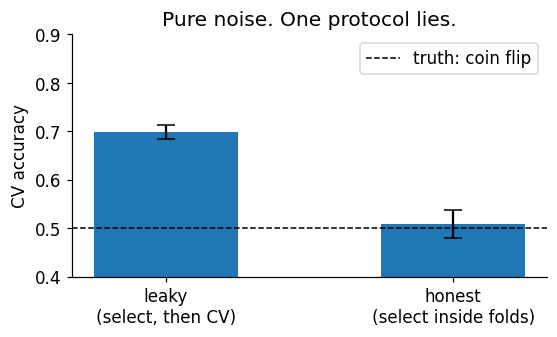

In [32]:
# ---- the leakage crime scene, reproduced on pure noise ----
r7 = np.random.default_rng(7)
accs_leaky, accs_honest = [], []
for rep in range(10):
    Xn = r7.normal(size=(400, 1000)).astype(np.float32)   # 1,000 noise features
    yn_ = r7.integers(0, 2, 400)                          # coin-flip labels
    fl = stratified_folds(yn_, 5, seed=rep)

    def top_corr(Xa, ya, k=20):                           # select k most correlated
        c = np.abs((Xa - Xa.mean(0)).T @ (ya - ya.mean()))
        return np.argsort(-c)[:k]

    cols_leak = top_corr(Xn, yn_)                         # SIN: test rows voted here
    for accs, cols_fn in [(accs_leaky,  lambda tr_i, _: cols_leak),
                          (accs_honest, lambda tr_i, m: top_corr(Xn[m], yn_[m]))]:
        f_acc = []
        for hold in fl:
            m = np.ones(400, bool); m[hold] = False
            cols = cols_fn(None, m)
            P = ridge_prep(Xn[m][:, cols], yn_[m], 2)
            f_acc.append(float((ridge_predict(ridge_solve(P, 1.0), Xn[hold][:, cols]) == yn_[hold]).mean()))
        accs.append(np.mean(f_acc))

print(f'labels are COIN FLIPS — true attainable accuracy: 0.500\n')
print(f'  select-then-CV (leaky):    {np.mean(accs_leaky):.3f} +/- {np.std(accs_leaky):.3f}')
print(f'  selection inside each fold: {np.mean(accs_honest):.3f} +/- {np.std(accs_honest):.3f}')

fig, ax = plt.subplots(figsize=(5.2, 3.2))
ax.bar(['leaky\n(select, then CV)', 'honest\n(select inside folds)'],
       [np.mean(accs_leaky), np.mean(accs_honest)],
       yerr=[np.std(accs_leaky), np.std(accs_honest)], capsize=6, width=.5)
ax.axhline(0.5, ls='--', color='k', lw=1, label='truth: coin flip')
ax.set_ylabel('CV accuracy'); ax.set_ylim(.4, .9); ax.legend()
ax.set_title('Pure noise. One protocol lies.')
plt.tight_layout(); plt.show()

**Read the crime scene.** With 1,000 noise columns and only 400 coin flips, *some*
columns correlate with the labels by luck. Selecting on all the data lets the held-out
fold's flips vote on which columns survive — so at judgment time, the "held-out" fold
meets features pre-tuned to its own noise. The honest protocol (selection re-run inside
each training fold) reports the truth: coin flip. (Briefing 1's sklearn version:
**0.815 vs 0.515** — this is Freedman 1983 / Ambroise & McLachlan 2002; real published
science has died of this.)

The rule, and it's absolute: **every data-dependent step — selection, scaling, resampling
— lives inside the fold.** In sklearn that's one idiom: put everything in a `Pipeline`,
cross-validate the pipeline.

```python
pipe = Pipeline([('tfidf', TfidfVectorizer()),
                 ('select', SelectKBest(chi2, k=1000)),
                 ('clf', LogisticRegression(class_weight='balanced'))])
GridSearchCV(pipe, {'clf__C': [0.01, 0.1, 1, 10]},
             scoring='f1_macro', cv=5)          # leakage-proof by construction
```

> **🎤 Act IV, what you say on stage:** *"Every knob so far, I chose in front of you by
> hand. Here's the honest machinery: macro-F1 because every hazard class gets one vote;
> cross-validation — which is just a for-loop, five train/judge rounds so every row is
> judged by a model that never saw it — and the error bars it gives you for free; the
> one-SE rule to prefer the simplest model within noise of the best; then a bake-off of
> model types on the same folds, picked on evidence. And the commandment that makes it
> all valid: every data-dependent step lives inside the fold. Break it and you conjure
> accuracy out of literal coin flips — our sklearn-verified version scored 0.815 on pure
> noise. In sklearn the fix is one idiom: Pipeline, then cross-validate the Pipeline."*

---
# Epilogue · The whole story in one screen

**Act II.** A feature is informative iff it's dependent on the class; score that
dependence *before* modeling (chi²: rare-decisive; MI: common-reliable; they disagree
informatively). Selection is a nearly-free compression (6,907 → 1,000 costs 0.001
macro-F1) — but the scores must be computed inside the training data only.

**Act III.** Flexible models fit noise with huge cancelling coefficients, so penalize
size: buy bias, sell variance, and the sum is a U — some leash is always better than
none. Ridge aims the shrinkage at the directions the data determines worst. L1's
constant pull produces exact zeros: **the model does Act II's job while training** (one
word → 225 words along one knob). The room has already used all of this: sklearn
regularizes by default (`C = 1/λ`), and `gpt_train.py` runs dropout + AdamW + finite
iterations on 31 params/char.

**Act IV.** The training set always votes for more freedom, so knobs need an outside
judge: stratified CV scored by macro-F1 (imbalance!), the one-SE rule for humility,
bake-offs on shared folds with SEs shown, and the absolute rule that selection/scaling
live inside the fold — or you'll validate coin flips at 80%.

**The handoffs** (each act ends by owing the next one something):
Act II ends owing *"can the model select for itself?"* → Act III's L1 pays it.
Act III ends owing *"who picks λ?"* → Act IV's CV pays it.
Act IV ends owing *"better features beat better knobs — what's the best representation?"*
→ the BERT close pays it.

| claim you'll make | where it's verified |
| --- | --- |
| monoxide/fire chi²-vs-MI inversion | Briefing 1 §2 + this nb Part 1 |
| 6,907 → 1,000 features costs 0.001 macro-F1 | Briefing 1 §5 (sklearn, verified) |
| bias² + var = MSE, U-curve, optimum ≈ half of OLS | Briefing 2 §3.3 + this nb Part 2 |
| shrink factors target weak directions (0.95 vs 0.34) | Briefing 2 §3.2 + this nb Part 2 |
| L1 dial: 1 word (F1 .747) → 225 words (.887) | Briefing 2 §5 (verified) + this nb Part 2 |
| tuning plateau 0.809, one-SE → λ=10 | Briefing 3/4 §3 + this nb Part 3 |
| bake-off .031/.640/.657/.810; TF-IDF pipeline .856 | Briefing 3/4 §4, Briefing 1 |
| leakage: 0.815 on coin flips (honest: 0.515) | Briefing 1 §8 + this nb Part 3 |
| majority baseline acc .229 vs macro-F1 .031 | Briefing 3/4 §2 + this nb Part 3 |

**Still on your pre-talk checklist:** workbook Run All (sklearn cells), the
`class_weight` delta (imbalance crash course §6), AdamW decay value from `*_meta.txt`,
colleague's BERT numbers (+ probe-or-fine-tune question).

*Every number printed in this notebook was computed live on `../data/cpsc_merged.csv`
when the notebook was executed top-to-bottom. Pure numpy + matplotlib — it will run
identically on your machine.*